In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [2]:
from tensorflow import keras

In [3]:
from keras.layers import Dense, Flatten, Input
from keras.models import Sequential
from keras.utils import to_categorical

In [4]:
data= pd.read_excel("silver_prices_data.xlsx")

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2524 entries, 0 to 2523
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            2524 non-null   datetime64[ns]
 1   Adj Close       2524 non-null   float64       
 2   Close           2524 non-null   float64       
 3   High            2524 non-null   float64       
 4   Low             2524 non-null   float64       
 5   Open            2524 non-null   float64       
 6   Volume          2524 non-null   int64         
 7   MA_50           2475 non-null   float64       
 8   MA_200          2325 non-null   float64       
 9   Daily_Return    2523 non-null   float64       
 10  Year            2524 non-null   int64         
 11  Month           2524 non-null   int64         
 12  Volatility_30d  2494 non-null   float64       
dtypes: datetime64[ns](1), float64(9), int64(3)
memory usage: 256.5 KB


In [6]:
data

,Date,Adj Close,Close,High,Low,Open,Volume,MA_50,MA_200,Daily_Return,Year,Month,Volatility_30d
0,2016-01-04,13.817000,13.817000,14.100000,13.817000,14.100000,27,NaN,NaN,NaN,2016,1,NaN
1,2016-01-05,13.949000,13.949000,13.949000,13.949000,13.949000,4,NaN,NaN,0.955345,2016,1,NaN
2,2016-01-06,13.957000,13.957000,14.065000,13.957000,14.000000,105,NaN,NaN,0.057348,2016,1,NaN
3,2016-01-07,14.335000,14.335000,14.340000,14.330000,14.335000,286,NaN,NaN,2.708320,2016,1,NaN
4,2016-01-08,13.908000,13.908000,14.060000,13.908000,14.060000,6,NaN,NaN,-2.978724,2016,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2519,2026-01-12,84.610001,84.610001,85.824997,82.000000,82.000000,575,60.35742,43.764615,7.258757,2026,1,76.402098
2520,2026-01-13,85.876999,85.876999,88.610001,84.589996,84.904999,341,61.10640,44.020780,1.497457,2026,1,74.927540
2521,2026-01-14,90.869003,90.869003,93.000000,88.705002,89.349998,470,61.96390,44.302840,5.812970,2026,1,75.756402
2522,2026-01-15,91.875999,91.875999,92.419998,86.129997,90.824997,390,62.84366,44.591430,1.108184,2026,1,75.449192


In [7]:
from sklearn.impute import SimpleImputer

In [8]:
data.dropna(inplace=True)

In [9]:
x= data.drop(columns=["Volume"])

In [10]:
y= data["Volatility_30d"].copy()

In [11]:
x.shape, y.shape

((2325, 12), (2325,))

In [12]:
x["Day"]= x["Date"].dt.day

In [13]:
x.drop(columns=["Date"], inplace=True)

In [14]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2325 entries, 199 to 2523
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Adj Close       2325 non-null   float64
 1   Close           2325 non-null   float64
 2   High            2325 non-null   float64
 3   Low             2325 non-null   float64
 4   Open            2325 non-null   float64
 5   MA_50           2325 non-null   float64
 6   MA_200          2325 non-null   float64
 7   Daily_Return    2325 non-null   float64
 8   Year            2325 non-null   int64  
 9   Month           2325 non-null   int64  
 10  Volatility_30d  2325 non-null   float64
 11  Day             2325 non-null   int32  
dtypes: float64(9), int32(1), int64(2)
memory usage: 227.1 KB


In [15]:
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.2,random_state=42)

In [16]:
x.shape, y.shape

((2325, 12), (2325,))

In [17]:
model= Sequential([
    Input(shape=(12,)),
    Dense(10, activation="relu"),
    Dense(8, activation="relu"),
    Dense(6, activation="relu"),
    Dense(4, activation="relu"),
    Dense(2, activation="relu"),
    Dense(1, activation="linear")
])

In [18]:
model.compile(
    optimizer="Adam",
    loss= "mean_squared_error",
    metrics=["accuracy"]
)

In [19]:
history= model.fit(x_train, y_train, epochs=20, batch_size=2, validation_split=0.2)

Epoch 1/20
744/744 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0000e+00 - loss: 124.4358 - val_accuracy: 0.0000e+00 - val_loss: 136.3342
Epoch 2/20
744/744 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.0000e+00 - loss: 106.3464 - val_accuracy: 0.0000e+00 - val_loss: 112.2263
Epoch 3/20
744/744 ━━━━━━━━━━━━━━━━━━━━ 1s 981us/step - accuracy: 0.0000e+00 - loss: 81.4536 - val_accuracy: 0.0000e+00 - val_loss: 87.4501
Epoch 4/20
744/744 ━━━━━━━━━━━━━━━━━━━━ 1s 978us/step - accuracy: 0.0000e+00 - loss: 58.1103 - val_accuracy: 0.0000e+00 - val_loss: 63.8766
Epoch 5/20
744/744 ━━━━━━━━━━━━━━━━━━━━ 1s 996us/step - accuracy: 0.0000e+00 - loss: 26.5066 - val_accuracy: 0.0000e+00 - val_loss: 24.5338
Epoch 6/20
744/744 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.0000e+00 - loss: 3.7743 - val_accuracy: 0.0000e+00 - val_loss: 0.5558
Epoch 7/20
744/744 ━━━━━━━━━━━━━━━━━━━━ 1s 983us/step - accuracy: 0.0000e+00 - loss: 0.5115 - val_accuracy: 0.0000e+00 - val_loss: 0.4306
Epoch 8/20
744/744 ━━━━━━━

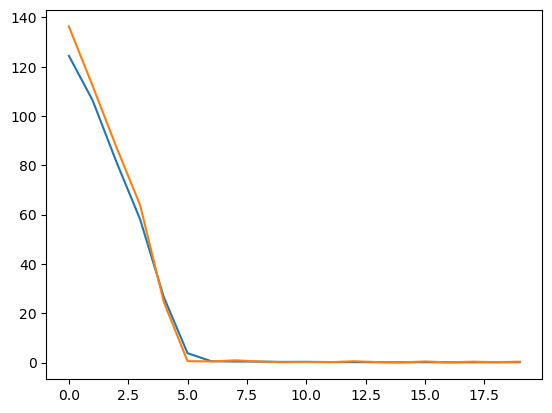

In [22]:
import matplotlib.pyplot as plt
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])


In [23]:
from sklearn.metrics import r2_score

In [24]:
y_pred= model.predict(x_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [27]:
r2_score(y_test, y_pred)

0.9969667716044834